In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/final_preprocessedv2_8PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,FRAME_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,39.0,-9.034594,21.247168,2.683200,12.696970,3.976160,-2.563228,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,27.0,25.389144,-55.417879,34.631625,20.236273,-0.880709,-2.820648,0.66
2,746.0,4355.0,5240.0,14699.0,894.0,723.0,27.0,-19.931322,-18.167155,8.725183,10.258672,3.037047,0.307626,7.86
3,750.0,8502.0,8416.0,8748.0,1127.0,1024.0,39.0,-38.491470,-15.676134,2.714543,1.786545,2.430626,1.966707,3.48
4,746.0,17845.0,18095.0,11380.0,1744.0,276.0,27.0,58.915081,55.849609,-15.308050,8.927246,2.424912,22.160814,1.19


In [2]:
X = df.drop(columns=["RANGE"])
y = df["RANGE"]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Neural Network Regression Performance on Test Set:
Mean Absolute Error: 2.6797
Mean Squared Error: 13.3719
R-squared: -1.4015


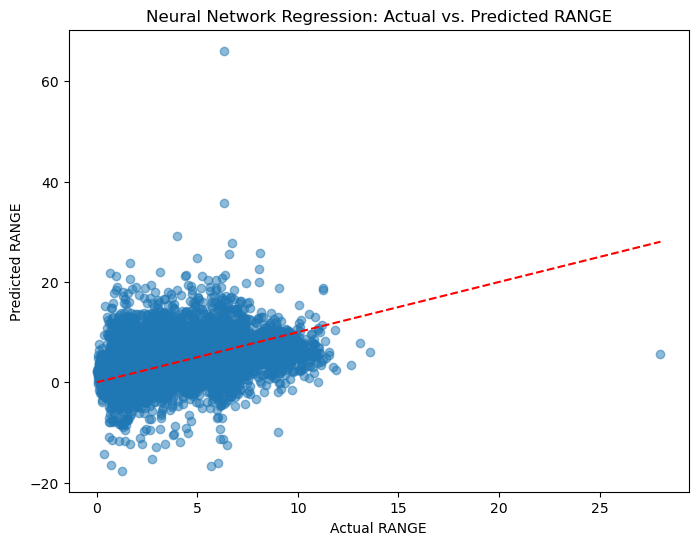

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Create and train the Neural Network Regressor
# Here we use one hidden layer with 100 neurons and allow up to 500 iterations.
nn_reg = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=111)
nn_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_nn = nn_reg.predict(X_test)

# 3. Evaluate the performance
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae_nn:.4f}")
print(f"Mean Squared Error: {mse_nn:.4f}")
print(f"R-squared: {r2_nn:.4f}")

# 4. Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("Neural Network Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


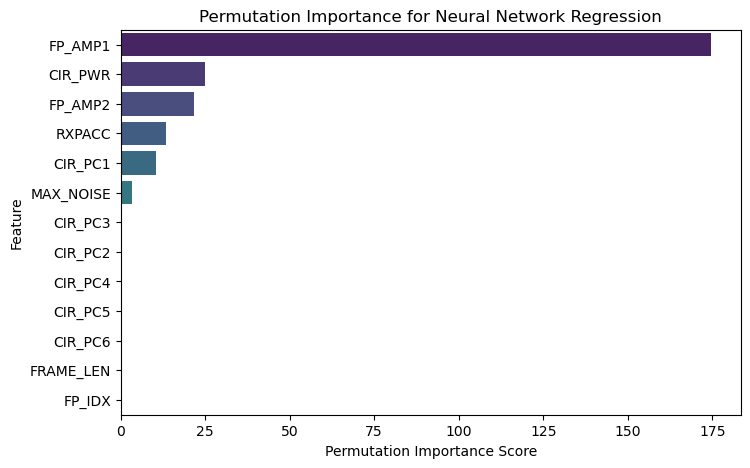

In [5]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute permutation importance for the neural network regressor
r = permutation_importance(nn_reg, X_test, y_test, n_repeats=10, random_state=111, scoring='neg_mean_squared_error')

# Convert the importances to a Pandas Series using feature names from X_test.columns
perm_importances = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

# Plot the permutation importances using a bar plot with hue assigned
plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)

# Remove the legend if it exists
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Neural Network Regression")
plt.show()


- Based on feature importance, can remove **PREAM_LEN, FP_IDX, CIR_PC5** (for dataset final_preprocessed_8PCs.cvs)

    - Mean Absolute Error: 5.123732892772155
    - Mean Squared Error: 38.276505398264305
    - R-squared: -12.907737897891291
  
- Based on feature importance, can remove **CIR_PC3/7** (for dataset final_preprocessed_8PCs_both.cvs)
    - Mean Absolute Error: 8.211980523861367
    - Mean Squared Error: 92.6675310742365
    - R-squared: -15.642694581657238

- Based on feature importance, can remove **STDEV_NOISE, NLOS, CIR_PC2/3/4/5/6/7/8, PREAM_LEN, FP_IDX** (for dataset final_preprocessed_8PCs_both_all.cvs)
  **(WORST ONE I FEEL)**
    - Mean Absolute Error: 11.959235352460883
    - Mean Squared Error: 172.71936878498434
    - R-squared: -30.019664274019835